# Data Preprocessing

In this phase, we prepare the dataset for machine learning by separating the features and target variable, encoding categorical data, splitting the dataset, and building a preprocessing pipeline. This ensures that the same preprocessing steps can be reused during model training and deployment.

## Step 1: Load the Processed Dataset

Load the cleaned dataset that was produced during the data cleaning phase.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder,PowerTransformer
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold

# import models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score,
                             roc_curve, precision_recall_curve, precision_score, recall_score, ConfusionMatrixDisplay)
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import ADASYN

In [2]:
df = pd.read_csv("../data/processed_data/processed_customer_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Feature Engineering

Feature engineering is the process of creating new meaningful features from the existing data to improve the predictive performance of machine learning models.

The engineered features are designed based on business understanding of customer behavior and are expected to provide additional information that may help distinguish customers who are likely to churn.

## Feature 1: Average Monthly Spend

This feature estimates the customer's average spending over their subscription period.

It is calculated by dividing the total charges by the customer tenure. Adding one month prevents division by zero for new customers.

In [3]:
df["AverageSpend"] = df["TotalCharges"] / (df["tenure"] + 1)

df[["TotalCharges", "tenure", "AverageSpend"]].head()

,TotalCharges,tenure,AverageSpend
0,29.85,1,14.925000
1,1889.50,34,53.985714
2,108.15,2,36.050000
3,1840.75,45,40.016304
4,151.65,2,50.550000


## Feature 2: Service Count

Customers subscribed to more services may exhibit different churn behavior.

This feature counts the number of services currently used by each customer.

In [4]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = (
    df[service_columns]
    .replace({
        "Yes": 1,
        "No": 0,
        "No phone service": 0,
        "No internet service": 0
    })
    .astype(int)
    .sum(axis=1)
)

df[["ServiceCount"]].head()

C:\Users\Estabrk1\AppData\Local\Temp\ipykernel_24560\1087295831.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


,ServiceCount
0,1
1,3
2,3
3,3
4,1


## Feature 3: New Customer Indicator

Customers with a short subscription period are generally more likely to churn.

A binary feature is created to identify customers with less than one year of tenure.

In [5]:
df["IsNewCustomer"] = (df["tenure"] < 12).astype(int)

df[["tenure", "IsNewCustomer"]].head()

,tenure,IsNewCustomer
0,1,1
1,34,0
2,2,1
3,45,0
4,2,1


## Verify the Engineered Features

Display the newly created features to ensure they were generated correctly.

In [6]:
df[["AverageSpend", "ServiceCount", "IsNewCustomer"]].describe()

,AverageSpend,ServiceCount,IsNewCustomer
count,7032.000000,7043.000000,7043.000000
mean,59.083067,3.362914,0.293767
std,30.514438,2.062031,0.455519
min,9.183333,0.000000,0.000000
25%,26.225944,1.000000,0.000000
50%,61.070387,3.000000,0.000000
75%,84.877538,5.000000,1.000000
max,118.969863,8.000000,1.000000


## Reusable Feature Engineering Function (for deployment)

The three engineered features above are wrapped into a single function so the **exact same logic** can be reused outside this notebook — e.g. in a Streamlit app or an MCP server — without copy-pasting or risking drift between training and inference.

This function should be moved to a shared module (e.g. `src/feature_engineering.py`) and imported both here and in the deployment code.


In [7]:
SERVICE_COLUMNS = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]


def engineer_features(input_df):
    """Apply the same feature engineering used during training.

    Parameters
    ----------
    input_df : pd.DataFrame
        Raw customer data containing the original Telco-Churn columns
        (tenure, TotalCharges, and the service columns).

    Returns
    -------
    pd.DataFrame
        Copy of input_df with AverageSpend, ServiceCount, and IsNewCustomer added.
    """
    out = input_df.copy()

    out["AverageSpend"] = out["TotalCharges"] / (out["tenure"] + 1)

    out["ServiceCount"] = (
        out[SERVICE_COLUMNS]
        .replace({
            "Yes": 1,
            "No": 0,
            "No phone service": 0,
            "No internet service": 0
        })
        .astype(int)
        .sum(axis=1)
    )

    out["IsNewCustomer"] = (out["tenure"] < 12).astype(int)

    return out


**Sanity check** — confirm the function reproduces the same values already created step-by-step above:


In [8]:
_check = engineer_features(df.drop(columns=["AverageSpend", "ServiceCount", "IsNewCustomer"]))
assert _check["AverageSpend"].equals(df["AverageSpend"])
assert _check["ServiceCount"].equals(df["ServiceCount"])
assert _check["IsNewCustomer"].equals(df["IsNewCustomer"])
print("engineer_features() matches the manual steps above.")


engineer_features() matches the manual steps above.


C:\Users\Estabrk1\AppData\Local\Temp\ipykernel_24560\4142315688.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
AverageSpend        11
ServiceCount         0
IsNewCustomer        0
dtype: int64

## Step 2: Separate Features and Target

The target variable is **Churn**, while **customerID** is removed because it is only an identifier and does not contribute to prediction.

In [10]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

## Step 3: Encode the Target Variable

Machine learning models require numerical labels. Therefore, the target variable is encoded as:

- No → 0
- Yes → 1

In [11]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [12]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_features].skew().sort_values(ascending=False)

SeniorCitizen     1.833633
TotalCharges      0.961642
IsNewCustomer     0.905744
ServiceCount      0.450807
tenure            0.239540
AverageSpend     -0.008862
MonthlyCharges   -0.220524
dtype: float64

## Step 4: Split the Dataset

The dataset is divided into training and testing sets.

A stratified split is used to preserve the original class distribution of the target variable.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (5634, 22)
Testing Set : (1409, 22)


## Cross Validation Strategy

Stratified K-Fold Cross Validation is used during model training.

This approach maintains the class distribution in each fold and provides a more reliable estimate of model performance.

In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train, y_train), 1):
    print(f"Fold {fold}")
    print("Train:", len(train_idx))
    print("Validation:", len(valid_idx))
    print("-" * 30)

Fold 1
Train: 4507
Validation: 1127
------------------------------
Fold 2
Train: 4507
Validation: 1127
------------------------------
Fold 3
Train: 4507
Validation: 1127
------------------------------
Fold 4
Train: 4507
Validation: 1127
------------------------------
Fold 5
Train: 4508
Validation: 1126
------------------------------


### Split Data to Categorical and Numerical features

In [15]:
# Target column
target = "Churn"

# Binary features
binary_features = [
    "SeniorCitizen",
    "IsNewCustomer"
]

# Numerical features (continuous)
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AverageSpend",
    "ServiceCount"
]

# Categorical features
categorical_features = [
    col for col in X.columns
    if col not in numeric_features + binary_features
]

print("Numerical Features:", numeric_features)
print("Binary Features:", binary_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'AverageSpend', 'ServiceCount']
Binary Features: ['SeniorCitizen', 'IsNewCustomer']
Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [16]:
print(f"Numerical Features ({len(numeric_features)}): {numeric_features}")
print(f"Binary Features ({len(binary_features)}): {binary_features}")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")

Numerical Features (5): ['tenure', 'MonthlyCharges', 'TotalCharges', 'AverageSpend', 'ServiceCount']
Binary Features (2): ['SeniorCitizen', 'IsNewCustomer']
Categorical Features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


# Data Preprocessing

Different machine learning algorithms have different preprocessing requirements.

To maximize model performance, separate preprocessing pipelines are created for linear models and tree-based models.

This approach ensures that each algorithm receives the most appropriate representation of the data while maintaining a clean and reusable workflow.

## Numerical Preprocessing for Linear Models

Continuous numerical features are imputed using the median strategy.

A Yeo-Johnson Power Transformation is then applied to reduce skewness, followed by standardization to ensure that all numerical variables are on a comparable scale.

In [17]:
numeric_linear_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

## Binary Features

Binary variables are only imputed when necessary.

No scaling or transformation is applied because these variables already represent categorical states.

In [18]:
binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

## Categorical Features

Categorical variables are imputed using the most frequent category and then encoded using One-Hot Encoding.

In [19]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

## Linear Model Preprocessor

This preprocessing pipeline is used for models that are sensitive to feature scaling, such as Logistic Regression.

In [20]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_linear_pipeline, numeric_features),
        ("bin", binary_pipeline, binary_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

## Numerical Preprocessing for Tree-Based Models

Tree-based algorithms do not require feature scaling.

Only missing values are handled for continuous numerical variables.

In [21]:
numeric_tree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

## Tree Model Preprocessor

This preprocessing pipeline is designed for tree-based algorithms such as Random Forest and XGBoost.

In [22]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_tree_pipeline, numeric_features),
        ("bin", binary_pipeline, binary_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

## Building Models

- logistic regression

In [23]:
lr_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

- random forest

In [24]:
rf_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

- xgboost

In [25]:
xgb_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

- catboost

In [26]:
cat_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", CatBoostClassifier(
        random_state=42,
        verbose=0
    ))
])

## Store All Models

The pipelines are stored in a dictionary to simplify training and evaluation.

In [27]:
models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "CatBoost": cat_pipeline
}

## Train the Models

Each model is trained using the training dataset.

In [28]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Random Forest trained successfully.
XGBoost trained successfully.
CatBoost trained successfully.


## Evaluate Model Performance

The trained models are evaluated using multiple classification metrics to provide a comprehensive assessment of their predictive performance.

The following metrics are used:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

In [29]:
results = []

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

In [30]:
results_df = pd.DataFrame(results)

results_df.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806955,0.673469,0.529412,0.592814,0.847674
3,CatBoost,0.797019,0.646667,0.518717,0.575668,0.839331
2,XGBoost,0.779276,0.600000,0.505348,0.548621,0.823529
1,Random Forest,0.783534,0.614618,0.494652,0.548148,0.824781


# Hyperparameter Tuning

Hyperparameter tuning is performed to optimize the performance of machine learning models.

RandomizedSearchCV is used together with Stratified K-Fold Cross Validation to efficiently search for the best combination of hyperparameters while maintaining the class distribution across folds.

## Hyperparameter Tuning: Logistic Regression

The Logistic Regression model is optimized using RandomizedSearchCV.

In [31]:
from scipy.stats import loguniform

lr_param_grid = {
    "classifier__C": loguniform(1e-3, 100),
    "classifier__solver": ["liblinear", "lbfgs"],
    "classifier__penalty": ["l2"]
}

In [32]:

lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=lr_param_grid,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

In [33]:
lr_search.fit(X_train, y_train)

c:\Users\Estabrk1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': <scipy.stats....002754B62BA70>, 'classifier__penalty': ['l2'], 'classifier__solver': ['liblinear', 'lbfgs']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV

## Best Logistic Regression Parameters

In [34]:
print("Best Parameters:")
print(lr_search.best_params_)

print("\nBest Cross Validation F1:")
print(lr_search.best_score_)

Best Parameters:
{'classifier__C': np.float64(0.04661686413912769), 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Best Cross Validation F1:
0.5994308252225512


In [35]:
best_lr = lr_search.best_estimator_

y_pred = best_lr.predict(X_test)
y_prob = best_lr.predict_proba(X_test)[:,1]


## Hyperparameter Tuning: Random Forest


In [36]:
from scipy.stats import randint

rf_params = {
    "classifier__n_estimators": randint(100, 500),
    "classifier__max_depth": [10, 20, 30, None],
    "classifier__min_samples_split": randint(2, 10),
    "classifier__min_samples_leaf": randint(1, 5),
    "classifier__max_features": ["sqrt", "log2"]
}

In [37]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [10, 20, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': <scipy.stats....002754C74C2F0>, 'classifier__min_samples_split': <scipy.stats....002754C766360>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the `

## Hyperparameter Tuning:Xgboost

In [38]:
xgb_params = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__gamma": [0, 1, 2]
}

In [39]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__gamma': [0, 1, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``p

## Hyperparameter Tuning : CatBoost

In [40]:
cat_params = {
    "classifier__iterations": [200, 300, 500],
    "classifier__depth": [4, 6, 8],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__l2_leaf_reg": [1, 3, 5, 7]
}

In [41]:
cat_search = RandomizedSearchCV(
    estimator=cat_pipeline,
    param_distributions=cat_params,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

cat_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__depth': [4, 6, ...], 'classifier__iterations': [200, 300, ...], 'classifier__l2_leaf_reg': [1, 3, ...], 'classifier__learning_rate': [0.01, 0.05, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict

#  Model Comparison After Hyperparameter Tuning

After tuning the hyperparameters of each machine learning model, their performance is compared using the same evaluation metrics.

The objective is to identify the model that provides the best balance between precision, recall, F1-score, and ROC-AUC for customer churn prediction.

In [42]:
tuned_models = {
    "Logistic Regression": lr_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "XGBoost": xgb_search.best_estimator_,
    "CatBoost": cat_search.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

In [43]:
tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804116,0.667808,0.521390,0.585586,0.846697
1,Random Forest,0.797019,0.653846,0.500000,0.566667,0.840705
2,XGBoost,0.801987,0.662116,0.518717,0.581709,0.845416
3,CatBoost,0.802697,0.667832,0.510695,0.578788,0.846591


## Compare Tuned Models

In [44]:
tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804116,0.667808,0.521390,0.585586,0.846697
2,XGBoost,0.801987,0.662116,0.518717,0.581709,0.845416
3,CatBoost,0.802697,0.667832,0.510695,0.578788,0.846591
1,Random Forest,0.797019,0.653846,0.500000,0.566667,0.840705


## Performance Improvement

The following table compares the baseline performance with the tuned models.

In [45]:
comparison = pd.DataFrame({
    "Model": results_df["Model"],
    "Baseline F1": results_df["F1 Score"].round(4),
    "Tuned F1": tuned_results_df["F1 Score"].round(4),
    "Improvement": (
        tuned_results_df["F1 Score"].values -
        results_df["F1 Score"].values
    ).round(4)
})

comparison

,Model,Baseline F1,Tuned F1,Improvement
0,Logistic Regression,0.5928,0.5856,-0.0072
1,Random Forest,0.5481,0.5667,0.0185
2,XGBoost,0.5486,0.5817,0.0331
3,CatBoost,0.5757,0.5788,0.0031


## Select the Best Model

The model with the highest F1-score and strong ROC-AUC performance is selected for the remaining stages of the project.

In [46]:
best_model_name = tuned_results_df.sort_values(
    "F1 Score",
    ascending=False
).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [47]:
best_model = tuned_models[best_model_name]

In [48]:
if hasattr(best_model, "best_params_"):
    print("Best Hyperparameters:")
    print(best_model.best_params_)

In [49]:

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



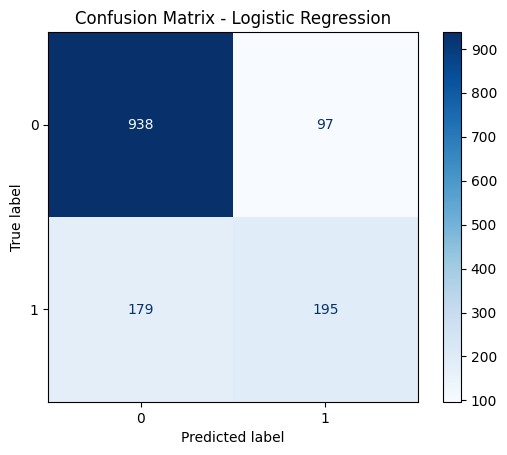

In [50]:

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

### Confusion Matrix Analysis

The Logistic Regression model correctly classified most customers.

- True Negatives (TN): 938
- False Positives (FP): 97
- False Negatives (FN): 179
- True Positives (TP): 195

Although the model performs well overall, it still misses a considerable number of churn customers (False Negatives). Since customer churn prediction aims to identify customers at risk before they leave, improving Recall is more important than maximizing Accuracy alone.

Threshold optimization will therefore be performed in the next phase to improve churn detection.

# Handling Class Imbalance

The customer churn dataset is imbalanced, with significantly fewer churn customers than non-churn customers.

To improve the model's ability to identify churn cases, Adaptive Synthetic Sampling (ADASYN) is applied to the training data only.

The testing dataset remains unchanged to ensure a fair evaluation.

In [51]:
best_params = lr_search.best_params_

lr_adasyn_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("adasyn", ADASYN(random_state=42)),
    ("classifier", LogisticRegression(
        C=float(best_params["classifier__C"]),
        penalty=best_params["classifier__penalty"],
        solver=best_params["classifier__solver"],
        random_state=42,
        max_iter=1000
    ))
])

In [52]:
lr_adasyn_pipeline.fit(X_train, y_train)

c:\Users\Estabrk1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,steps,"[('preprocessor', ...), ('adasyn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](22,)","['gender','SeniorCitizen','Partner',...,'AverageSpend','ServiceCount', 'IsNewCustomer']"
n_features_in_,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [53]:
y_pred_adasyn = lr_adasyn_pipeline.predict(X_test)

y_prob_adasyn = lr_adasyn_pipeline.predict_proba(X_test)[:, 1]

In [54]:

adasyn_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy_score(y_test, y_pred_adasyn),
        precision_score(y_test, y_pred_adasyn),
        recall_score(y_test, y_pred_adasyn),
        f1_score(y_test, y_pred_adasyn),
        roc_auc_score(y_test, y_prob_adasyn)
    ]
})

adasyn_results

,Metric,Value
0,Accuracy,0.724627
1,Precision,0.488818
2,Recall,0.818182
3,F1 Score,0.612000
4,ROC-AUC,0.846137


In [55]:

print(classification_report(y_test, y_pred_adasyn))

              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1035
           1       0.49      0.82      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.72      0.74      1409



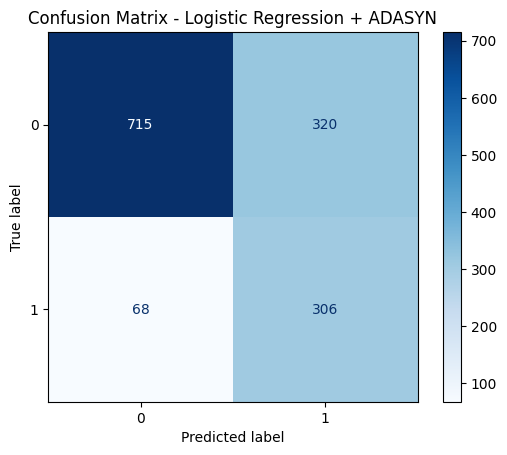

In [56]:

ConfusionMatrixDisplay.from_estimator(
    lr_adasyn_pipeline,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression + ADASYN")

plt.show()

In [57]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Before ADASYN": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ],
    "After ADASYN": [
        accuracy_score(y_test, y_pred_adasyn),
        precision_score(y_test, y_pred_adasyn),
        recall_score(y_test, y_pred_adasyn),
        f1_score(y_test, y_pred_adasyn),
        roc_auc_score(y_test, y_prob_adasyn)
    ]
})

comparison

,Metric,Before ADASYN,After ADASYN
0,Accuracy,0.804116,0.724627
1,Precision,0.667808,0.488818
2,Recall,0.521390,0.818182
3,F1 Score,0.585586,0.612000
4,ROC-AUC,0.846591,0.846137


# ADASYN Performance Analysis

Applying ADASYN significantly improved the model's ability to identify churn customers.

### Observations

- Recall increased from **52.14%** to **81.82%**.
- F1 Score improved from **0.5856** to **0.6120**.
- ROC-AUC remained almost unchanged.
- Precision decreased due to the increase in predicted churn cases.
- Accuracy also decreased because the model became more sensitive to the minority class.

Since customer churn prediction focuses on identifying customers at risk of leaving, improving Recall and F1 Score is considered more valuable than maximizing Accuracy.

# Threshold Optimization

By default, Logistic Regression classifies a customer as churn if the predicted probability is greater than or equal to 0.50.

However, the default threshold is not always optimal for imbalanced classification problems.

Different probability thresholds are evaluated to identify the threshold that provides the best balance between Precision and Recall, using the F1 Score as the primary evaluation metric.

In [58]:
y_prob = lr_adasyn_pipeline.predict_proba(X_test)[:, 1]

In [59]:
thresholds = np.unique(y_prob)

In [60]:

threshold_results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.03,0.265436,1.000000,0.419518
1,0.03,0.265625,1.000000,0.419753
2,0.03,0.265814,1.000000,0.419989
3,0.03,0.266003,1.000000,0.420225
4,0.03,0.266192,1.000000,0.420461
...,...,...,...,...
1402,0.94,1.000000,0.013369,0.026385
1403,0.94,1.000000,0.010695,0.021164
1404,0.95,1.000000,0.008021,0.015915
1405,0.96,1.000000,0.005348,0.010638


## Threshold Performance Analysis

The relationship between Precision, Recall, and F1 Score is visualized across different probability thresholds.

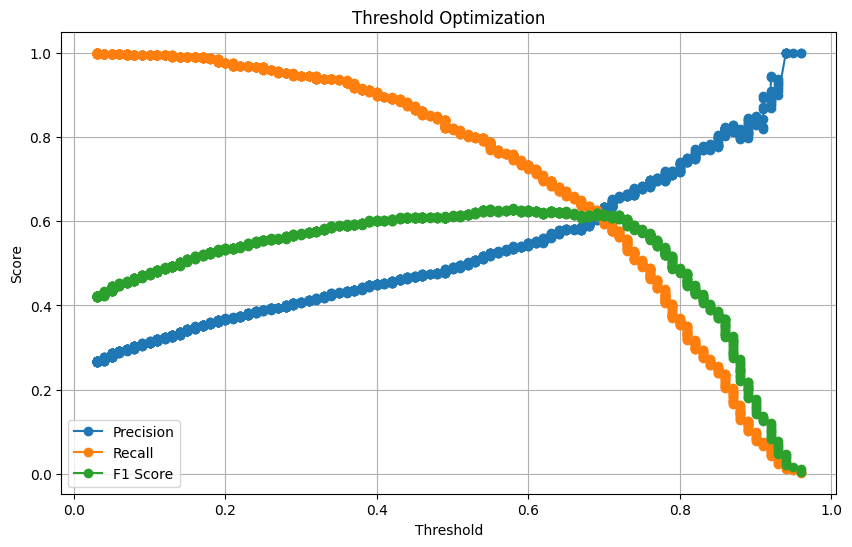

In [61]:

plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")

plt.grid(True)

plt.legend()

plt.show()

### Select the Optimal Threshold

The threshold with the highest F1 Score is selected from `threshold_df` (this step was missing in the original notebook, which caused a `NameError`).


In [62]:
best_threshold = threshold_df.loc[threshold_df["F1 Score"].idxmax()]
print("Best threshold row:")
print(best_threshold)


Best threshold row:
Threshold    0.580000
Precision    0.540076
Recall       0.756684
F1 Score     0.630290
Name: 884, dtype: float64


In [63]:
best_threshold_value = best_threshold["Threshold"]

y_pred_best = (
    y_prob >= best_threshold_value
).astype(int)

In [64]:

print(classification_report(y_test, y_pred_best))

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.75      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

Accuracy : 0.7629524485450674
ROC-AUC  : 0.8461365573897542


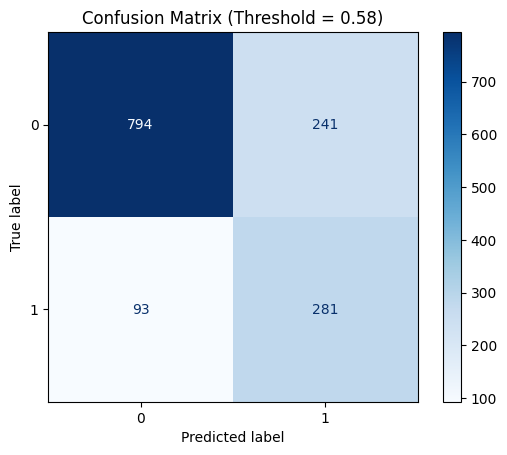

In [65]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    cmap="Blues"
)

plt.title(
    f"Confusion Matrix (Threshold = {best_threshold_value:.2f})"
)

plt.show()

# Threshold Optimization Results

The probability threshold was optimized using all unique prediction probabilities generated by the Logistic Regression model.

The default threshold (0.50) was compared with alternative thresholds, and the optimal threshold was selected based on the highest F1 Score.

### Best Threshold

- Threshold: **0.58**
- Precision: **0.540**
- Recall: **0.757**
- F1 Score: **0.630**

Increasing the threshold from 0.50 to 0.58 reduced false positive predictions while maintaining a high recall, resulting in the best overall balance between Precision and Recall.

In [66]:

def evaluate_model(name, model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [67]:
rf_adasyn_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("adasyn", ADASYN(random_state=42)),
    ("classifier", RandomForestClassifier(
        **{
            k.replace("classifier__", ""): v
            for k, v in rf_search.best_params_.items()
        },
        random_state=42,
        n_jobs=-1
    ))
])

In [68]:
rf_adasyn_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('adasyn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](22,)","['gender','SeniorCitizen','Partner',...,'AverageSpend','ServiceCount', 'IsNewCustomer']"
n_features_in_,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [69]:
xgb_adasyn_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("adasyn", ADASYN(random_state=42)),
    ("classifier", XGBClassifier(
        **{
            k.replace("classifier__", ""): v
            for k, v in xgb_search.best_params_.items()
        },
        random_state=42,
        eval_metric="logloss"
    ))
])

In [70]:
cat_adasyn_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("adasyn", ADASYN(random_state=42)),
    ("classifier", CatBoostClassifier(
        **{
            k.replace("classifier__", ""): v
            for k, v in cat_search.best_params_.items()
        },
        random_state=42,
        verbose=0
    ))
])

In [71]:
models = {
    "Logistic Regression + ADASYN": lr_adasyn_pipeline,
    "Random Forest + ADASYN": rf_adasyn_pipeline,
    "XGBoost + ADASYN": xgb_adasyn_pipeline,
    "CatBoost + ADASYN": cat_adasyn_pipeline
}

for model in models.values():
    model.fit(X_train, y_train)

c:\Users\Estabrk1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [72]:
comparison = pd.DataFrame([
    evaluate_model(name, model, X_test, y_test)
    for name, model in models.items()
])

comparison.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression + ADASYN,0.724627,0.488818,0.818182,0.612000,0.846137
1,CatBoost + ADASYN,0.792761,0.613889,0.590909,0.602180,0.844430
2,XGBoost + ADASYN,0.792761,0.614525,0.588235,0.601093,0.845061
3,Random Forest + ADASYN,0.777857,0.574572,0.628342,0.600255,0.834598


# Final Model Selection

After evaluating all baseline models, tuning their hyperparameters, and applying ADASYN to address class imbalance, a comprehensive comparison was performed using identical preprocessing pipelines and evaluation metrics.

Although CatBoost and XGBoost achieved slightly higher Accuracy, Logistic Regression consistently provided:

- The highest F1 Score.
- The highest ROC-AUC.
- The highest Recall.

Since customer churn prediction focuses on identifying customers who are likely to leave the service, Recall and F1 Score were considered more important than Accuracy.

Therefore, Logistic Regression was selected as the final machine learning model.

#  Explainable AI (SHAP)

Machine learning models often provide accurate predictions without explaining the reasons behind them.

To improve transparency and interpretability, SHAP (SHapley Additive exPlanations) is used to quantify the contribution of each feature to the model's predictions.

SHAP helps identify which customer characteristics increase or decrease the probability of churn, making the model more trustworthy and actionable.

In [73]:
preprocessor = lr_adasyn_pipeline.named_steps["preprocessor"]

classifier = lr_adasyn_pipeline.named_steps["classifier"]

In [74]:
X_test_processed = preprocessor.transform(X_test)

In [75]:
feature_names = preprocessor.get_feature_names_out()

In [76]:
import shap

explainer = shap.LinearExplainer(
    classifier,
    X_test_processed
)

shap_values = explainer(X_test_processed)

Background dataset has 1409 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1409 when initializing the masker.


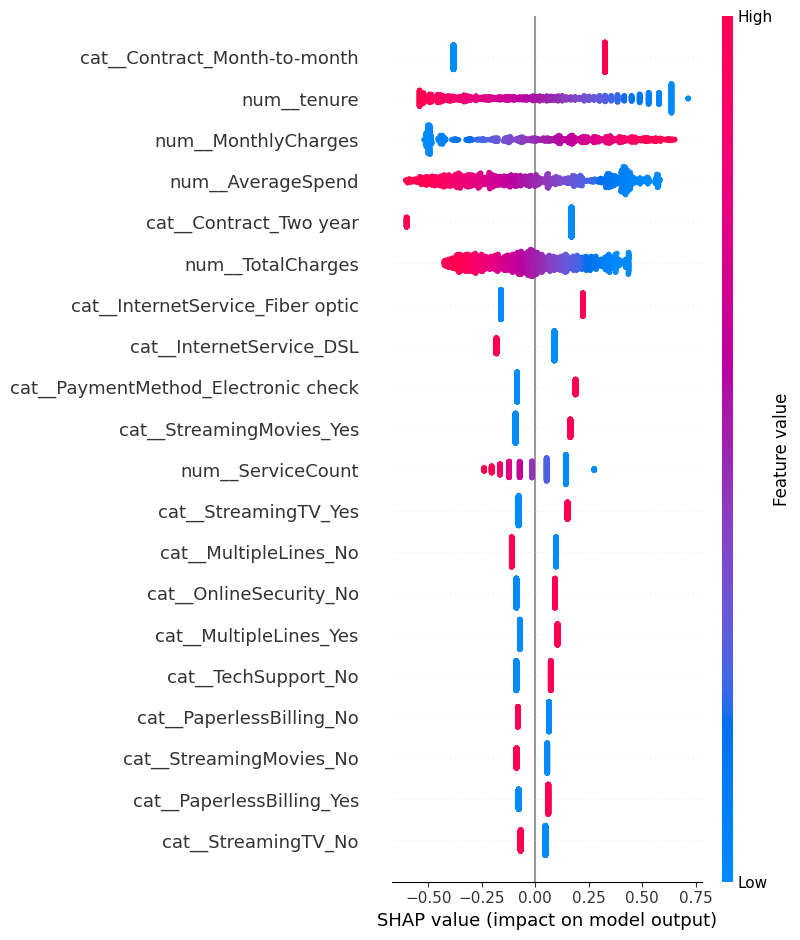

In [77]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

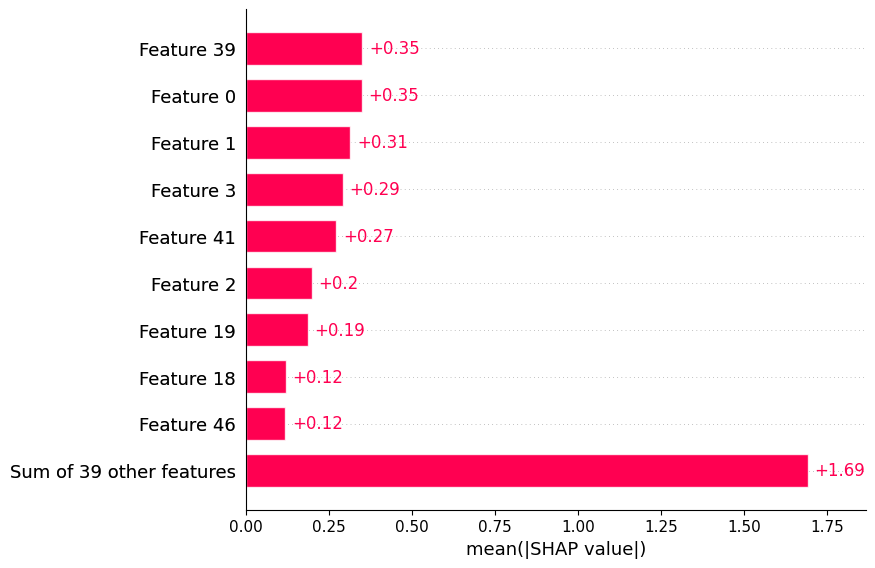

In [78]:
shap.plots.bar(shap_values)

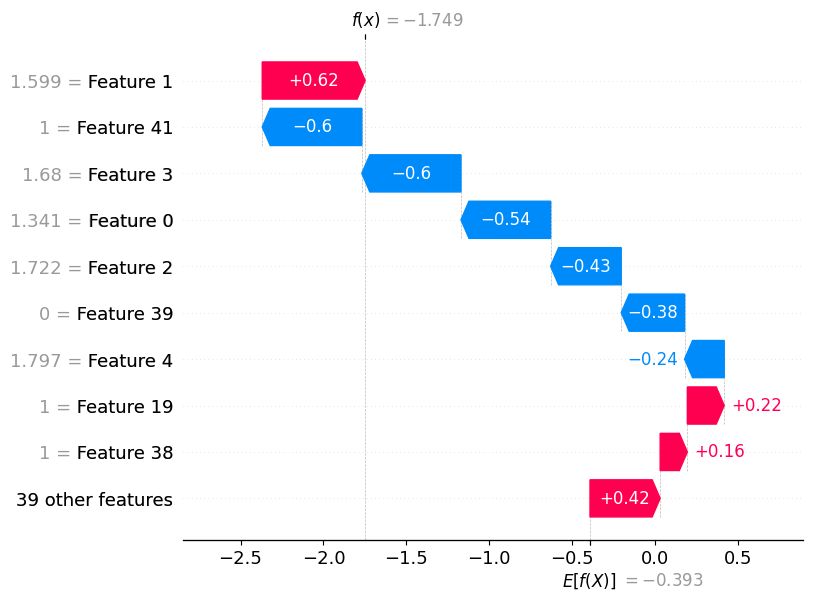

In [79]:
shap.plots.waterfall(shap_values[0])

In [80]:
shap.initjs()

shap.plots.force(shap_values[0])

# SHAP Analysis

The SHAP summary plot ranks features according to their overall contribution to churn prediction.

Positive SHAP values increase the probability of customer churn, while negative values reduce it.

This analysis provides valuable business insights by highlighting the key factors influencing customer retention.

# Save the Final Model

The final machine learning artifacts are saved to ensure reproducibility and enable seamless deployment.

The following components are stored:

- Trained prediction pipeline
- Optimized decision threshold
- Feature names

In [81]:
from pathlib import Path

Path("../model").mkdir(parents=True, exist_ok=True)

In [82]:
import joblib

joblib.dump(
    lr_adasyn_pipeline,
    "../model/final_model.pkl"
)

['../model/final_model.pkl']

In [83]:
BEST_THRESHOLD = 0.58

joblib.dump(
    BEST_THRESHOLD,
    "../model/decision_threshold.pkl"
)

['../model/decision_threshold.pkl']

In [84]:
joblib.dump(
    list(feature_names),
    "../model/feature_names.pkl"
)

['../model/feature_names.pkl']

In [85]:
model_info = {
    "model": "Logistic Regression",
    "sampling": "ADASYN",
    "threshold": BEST_THRESHOLD,
    "target": "Churn",
    "metric": "F1 Score",
    "f1_score": 0.630290,
    "roc_auc": 0.846137
}

joblib.dump(
    model_info,
    "../model/model_info.pkl"
)

['../model/model_info.pkl']

## Save Additional Deployment Artifacts

Two more artifacts are saved to make building the Streamlit app and MCP server straightforward, without having to re-derive them from the training data:

- **`label_encoder.pkl`** — the fitted `LabelEncoder` for the target, so predictions/labels can be decoded consistently if needed.
- **`input_schema.pkl`** — the raw (pre-engineering) input column names, their dtypes, and the allowed categories for each categorical column. This lets a UI (Streamlit form) or an MCP tool validate/build inputs dynamically instead of hardcoding the schema by hand.


In [86]:
joblib.dump(
    label_encoder,
    "../model/label_encoder.pkl"
)

raw_input_columns = [c for c in X.columns]

input_schema = {
    "columns": raw_input_columns,
    "dtypes": {c: str(X[c].dtype) for c in raw_input_columns},
    "categorical_options": {
        c: sorted(X[c].dropna().unique().tolist())
        for c in X.select_dtypes(include=["object", "string"]).columns
    },
    "numeric_ranges": {
        c: (float(X[c].min()), float(X[c].max()))
        for c in ["tenure", "MonthlyCharges", "TotalCharges"]
    }
}

joblib.dump(
    input_schema,
    "../model/input_schema.pkl"
)

input_schema


{'columns': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'tenure',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'MonthlyCharges',
  'TotalCharges',
  'AverageSpend',
  'ServiceCount',
  'IsNewCustomer'],
 'dtypes': {'gender': 'object',
  'SeniorCitizen': 'int64',
  'Partner': 'object',
  'Dependents': 'object',
  'tenure': 'int64',
  'PhoneService': 'object',
  'MultipleLines': 'object',
  'InternetService': 'object',
  'OnlineSecurity': 'object',
  'OnlineBackup': 'object',
  'DeviceProtection': 'object',
  'TechSupport': 'object',
  'StreamingTV': 'object',
  'StreamingMovies': 'object',
  'Contract': 'object',
  'PaperlessBilling': 'object',
  'PaymentMethod': 'object',
  'MonthlyCharges': 'float64',
  'TotalCharges': 'float64',
  'AverageSpend': 'float64',
  'ServiceCount': 'int64',
 

In [87]:
loaded_pipeline = joblib.load("../model/final_model.pkl")
loaded_threshold = joblib.load("../model/decision_threshold.pkl")
loaded_features = joblib.load("../model/feature_names.pkl")
loaded_info = joblib.load("../model/model_info.pkl")
loaded_label_encoder = joblib.load("../model/label_encoder.pkl")
loaded_schema = joblib.load("../model/input_schema.pkl")

print(type(loaded_pipeline))
print(loaded_threshold)
print(len(loaded_features))
print(loaded_info)
print(loaded_label_encoder.classes_)
print(loaded_schema["columns"])


<class 'imblearn.pipeline.Pipeline'>
0.58
48
{'model': 'Logistic Regression', 'sampling': 'ADASYN', 'threshold': 0.58, 'target': 'Churn', 'metric': 'F1 Score', 'f1_score': 0.63029, 'roc_auc': 0.846137}
['No' 'Yes']
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'AverageSpend', 'ServiceCount', 'IsNewCustomer']


In [88]:
def predict_customer(raw_customer_df):
    """Predict churn for one or more customers given RAW input
    (i.e. the original Telco-Churn columns, before feature engineering).

    This applies engineer_features() internally so the same function can be
    called directly from a Streamlit form or an MCP tool with raw user input.
    """
    customer_df = engineer_features(raw_customer_df)

    probability = float(
        loaded_pipeline.predict_proba(customer_df)[0, 1]
    )

    prediction = probability >= loaded_threshold

    if probability >= 0.80:
        risk = "Very High"
    elif probability >= 0.60:
        risk = "High"
    elif probability >= 0.40:
        risk = "Medium"
    else:
        risk = "Low"

    return {
        "prediction": "Churn" if prediction else "No Churn",
        "churn_probability": round(probability, 4),
        "confidence": f"{probability*100:.2f}%",
        "risk_level": risk,
    }


In [89]:
# Demo with RAW input (as it would arrive from a Streamlit form / MCP tool call),
# i.e. before AverageSpend / ServiceCount / IsNewCustomer are added.
raw_sample = X_test.drop(columns=["AverageSpend", "ServiceCount", "IsNewCustomer"]).iloc[[0]]

predict_customer(raw_sample)


C:\Users\Estabrk1\AppData\Local\Temp\ipykernel_24560\4142315688.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


{'prediction': 'No Churn',
 'churn_probability': 0.1482,
 'confidence': '14.82%',
 'risk_level': 'Low'}